In [21]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # MATLAB-like way of plotting
# sklearn package for machine learning in python:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score

In [33]:
# generate regression data set
X, y = make_regression(n_samples=200, n_features=2, noise=100, random_state=0)

#### Multiple regression happens right here:
 - You're generating data with 2 input features.
 - Because X has two columns, the model learns two coefficients — one for each feature.
 - This is Multiple Linear Regression because:
 - y=b0​+b1​⋅X1​+b2​⋅X2​

In [34]:
# split the data into training and test sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 1/3, random_state=0)

In [35]:
# fit the linear least-squres regression line to the training data:
regr = LinearRegression()
regr.fit(X_train, y_train)

LinearRegression()

In [36]:
# The coefficients
print('Coefficients: ', regr.coef_)

# The intercept
print('Intercept: ', regr.intercept_)

# The mean squared error
print('Mean squared error: %.8f'
% mean_squared_error(y_test, regr.predict(X_test)))

# The R^2 value:
print('Coefficient of determination: %.2f'
% r2_score(y_test, regr.predict(X_test)))

Coefficients:  [22.94570167 37.60876504]
Intercept:  -12.23179108458677
Mean squared error: 13573.70900732
Coefficient of determination: 0.06


In [37]:
print('Predict single value: ', regr.predict(np.array([[6,7]])))

Predict single value:  [388.7037742]


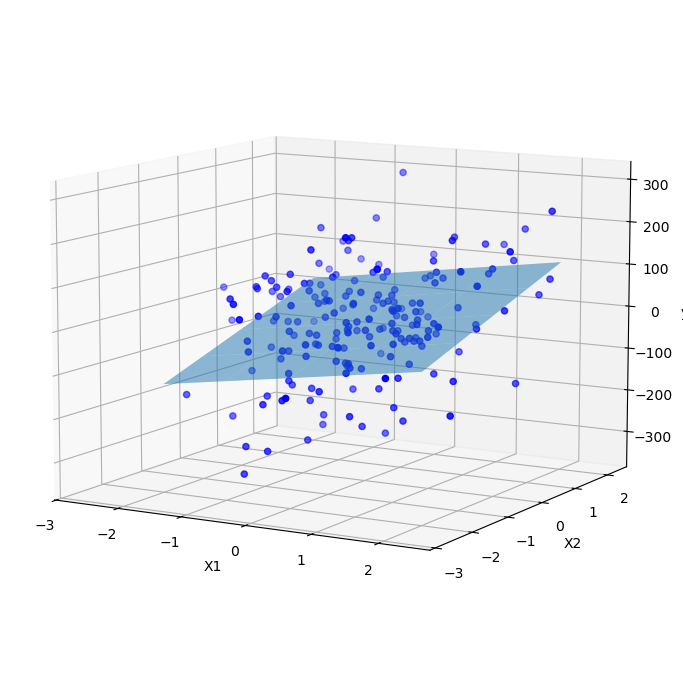

In [49]:
#3d plot for multiple linear regression:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.add_subplot(111, projection = '3d')
ax1.scatter(X[:,0], X[:,1], y, color = 'blue')

# plot the plane
X1, X2 = np.meshgrid(range(-2,3), range(-2,3))
Z = regr.coef_[0]*X1+regr.coef_[1]*X2+regr.intercept_
ax1.plot_surface(X1, X2, Z, alpha=0.5)
ax1.azim = -60
ax1.dist = 10

ax1.elev = 10
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('y')
fig1.tight_layout(pad=-2.0)